In [1]:
from torchvision import datasets
from torchvision.transforms import ToTensor
import wandb

W & B initialization

In [2]:
wandb.init(
    project='mnist',
    entity='malek-mohamed12345678-german-university-in-cairo'
)

wandb: Currently logged in as: gasser-ali-emara (malek-mohamed12345678-german-university-in-cairo) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Data

In [3]:
train_data = datasets.MNIST(
    root='data',
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.MNIST(
    root='data',
    train=False,
    download=True,
    transform=ToTensor()
)


Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting data\MNIST\raw\train-images-idx3-ubyte.gz to data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting data\MNIST\raw\train-labels-idx1-ubyte.gz to data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



...

Extracting data\FashionMNIST\raw\train-labels-idx1-ubyte.gz to data\FashionMNIST\raw



100.0%


Extracting data\FashionMNIST\raw\t10k-images-idx3-ubyte.gz to data\FashionMNIST\raw



100.0%

Extracting data\FashionMNIST\raw\t10k-labels-idx1-ubyte.gz to data\FashionMNIST\raw



Data loader

In [4]:
from torch.utils.data import DataLoader

loader = {
    'train': DataLoader(train_data, batch_size=wandb.config.batch_size, shuffle=True, num_workers=1),
    'test': DataLoader(test_data, batch_size=wandb.config.batch_size, shuffle=True, num_workers=1)
}


AttributeError: <class 'wandb.sdk.wandb_config.Config'> object has no attribute 'batch_size'

Model Architecture

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.cov1 = nn.Conv2d(in_channels=1, out_channels=10, kernel_size=5)
        self.conv2 = nn.Conv2d(in_channels=10, out_channels=20, kernel_size=5)
        self.conv2_drop = nn.Dropout2d()

        self.fc1 = nn.Linear(320, 50)
        self.fc2 = nn.Linear(50, 10)

    def forward(self, x):
      x = F.relu(F.max_pool2d(self.cov1(x), 2))
      x = F.relu(F.max_pool2d(self.conv2_drop(self.conv2(x)), 2))
      x = x.view(-1, 320)
      x = F.relu(self.fc1(x))
      x = F.dropout(x, training=self.training)
      x = self.fc2(x)

      return F.softmax(x, dim=1)



Optimization

In [ ]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
model = CNN().to(device)
if wandb.config.optimizer == 'adam':
  optimizer = optim.Adam(model.parameters(), lr=wandb.config.learning_rate)
elif wandb.config.optimizer == 'sgd':
  optimizer = optim.SGD(model.parameters(), lr=wandb.config.learning_rate, momentum=0.9)
elif wandb.config.optimizer == 'rmsprop':
  optimizer = optim.RMSprop(model.parameters(), lr=wandb.config.learning_rate, alpha=0.9)
loss_fn = nn.CrossEntropyLoss()

def train(epoch):
  model.train()
  for batch_idx, (data, target) in enumerate(loader['train']):
    data, target = data.to(device), target.to(device)
    optimizer.zero_grad()
    output = model(data)
    loss = loss_fn(output, target)
    loss.backward()
    optimizer.step()
    if(batch_idx%2000 == 0):
      print(f'Train Epoch: {epoch} [{batch_idx * len(data)}/{len(loader["train"].dataset)} ({100. * batch_idx / len(loader["train"])}%)]\t{loss.item():.6f}')



Using device: cpu


In [ ]:
def test():
  model.eval()

  test_loss = 0
  correct = 0

  with torch.no_grad():
    for data, target in loader['test']:
      data, target = data.to(device), target.to(device)
      output = model(data)
      test_loss += loss_fn(output, target).item()
      pred = output.argmax(1, keepdim=True)
      correct += pred.eq(target.view_as(pred)).sum().item()

  test_loss /= len(loader['test'])
  print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
    test_loss, correct, len(loader['test'].dataset),
    100. * correct / len(loader['test'].dataset)))

In [ ]:
for epoch in range(wandb.config.epochs):
  wandb.log({"loss": test_loss, "epoch": epoch})
  train(epoch)
  test()

Train Epoch: 1 [0/60000 (0.0%)]	2.305598

Test set: Average loss: 2.4009, Accuracy: 345/10000 (3%)

Train Epoch: 2 [0/60000 (0.0%)]	1.528281

Test set: Average loss: 2.3996, Accuracy: 420/10000 (4%)

Train Epoch: 3 [0/60000 (0.0%)]	1.562144

Test set: Average loss: 2.4025, Accuracy: 393/10000 (4%)

Train Epoch: 4 [0/60000 (0.0%)]	1.569402

Test set: Average loss: 2.3919, Accuracy: 551/10000 (6%)

Train Epoch: 5 [0/60000 (0.0%)]	1.579247

Test set: Average loss: 2.4036, Accuracy: 455/10000 (5%)

Train Epoch: 6 [0/60000 (0.0%)]	1.510858

Test set: Average loss: 2.3993, Accuracy: 453/10000 (5%)

Train Epoch: 7 [0/60000 (0.0%)]	1.582118

Test set: Average loss: 2.3994, Accuracy: 456/10000 (5%)

Train Epoch: 8 [0/60000 (0.0%)]	1.551818

Test set: Average loss: 2.3995, Accuracy: 445/10000 (4%)

Train Epoch: 9 [0/60000 (0.0%)]	1.548042

Test set: Average loss: 2.4010, Accuracy: 474/10000 (5%)



Predicted: 2


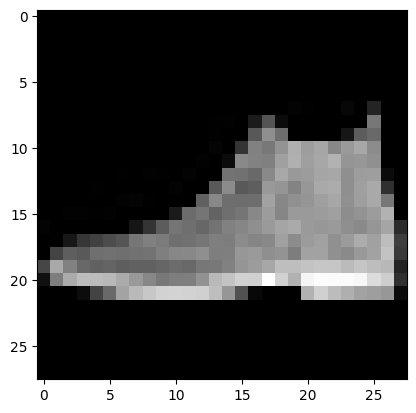

In [ ]:
import matplotlib.pyplot as plt

model.eval()

data,target = test_data[0]
data = data.unsqueeze(0).to(device)

output = model(data)

pred = output.argmax(1, keepdim=True).item()

print(f'Predicted: {pred}')

image = data.squeeze(0).squeeze(0).cpu().numpy()

plt.imshow(image, cmap='gray')  
plt.show()